# Homework 09: Feature Engineering
Features respond directly to Stage 08 findings and are constructed using past information only.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
P=Path.cwd().resolve(); P=P if P.name=='homework09' else P/'homework'/'homework09'
sys.path.insert(0,str(P))
from src.features import build_features
raw=pd.read_csv(P.parent/'homework08/data/raw/aapl_prices.csv')
features=build_features(raw)

## Feature rationale
- **return_lag1:** Stage 08 found weak persistence; this tests it without future leakage.
- **rolling_mean_5 / rolling_std_10:** summarize short trend and changing volatility seen in EDA. Both are shifted before rolling.
- **momentum_5:** captures whether the prior five sessions had directional persistence.
- **weekday one-hot indicators:** satisfy categorical encoding and test the EDA calendar assumption without imposing an artificial ordinal scale.

In [2]:
feature_cols=['return_lag1','rolling_mean_5','rolling_std_10','momentum_5']+[c for c in features if c.startswith('dow_')]
model_df=features.dropna(subset=feature_cols+['target_next_return']).copy()
out=P/'data/processed/aapl_features.csv'; out.parent.mkdir(parents=True,exist_ok=True); model_df.to_csv(out,index=False)
print(model_df.shape, out.relative_to(P)); display(model_df[feature_cols+['target_next_return']].head())

(240, 13) data/processed/aapl_features.csv


,return_lag1,rolling_mean_5,rolling_std_10,momentum_5,dow_Friday,dow_Monday,dow_Thursday,dow_Tuesday,dow_Wednesday,target_next_return
11,-0.032259,-0.009906,0.018285,-0.048979,0,0,1,0,0,0.017563
12,0.014286,-0.008148,0.018844,-0.040662,1,0,0,0,0,0.011236
13,0.017563,-0.004560,0.019485,-0.023447,0,1,0,0,0,0.006126
14,0.011236,-0.000803,0.019725,-0.004961,0,0,0,1,0,0.003527
15,0.006126,0.003390,0.019243,0.016215,0,0,0,0,1,-0.004645


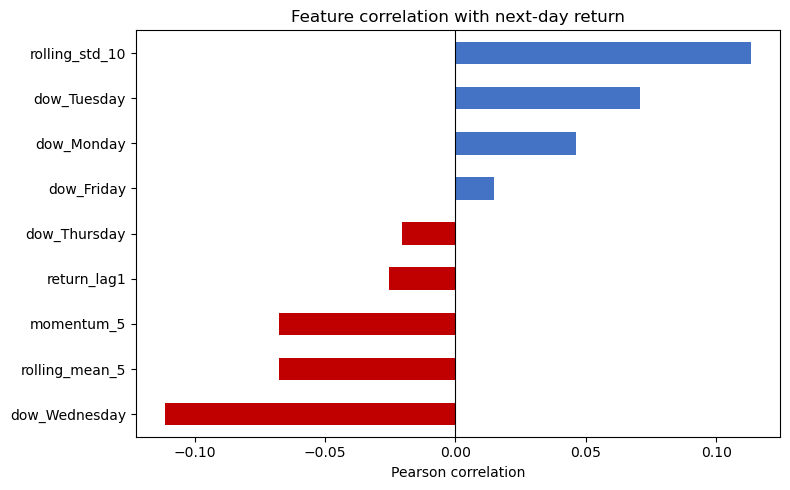

,correlation
dow_Wednesday,-0.111387
rolling_mean_5,-0.067816
momentum_5,-0.067540
return_lag1,-0.025336
dow_Thursday,-0.020412
dow_Friday,0.014820
dow_Monday,0.046396
dow_Tuesday,0.070685
rolling_std_10,0.113269


In [3]:
corr=model_df[feature_cols+['target_next_return']].corr()['target_next_return'].drop('target_next_return').sort_values()
ax=corr.plot.barh(figsize=(8,5),color=['#C00000' if x<0 else '#4472C4' for x in corr]); ax.set(title='Feature correlation with next-day return',xlabel='Pearson correlation'); ax.axvline(0,color='black',lw=.8); plt.tight_layout(); plt.show(); display(corr.to_frame('correlation'))

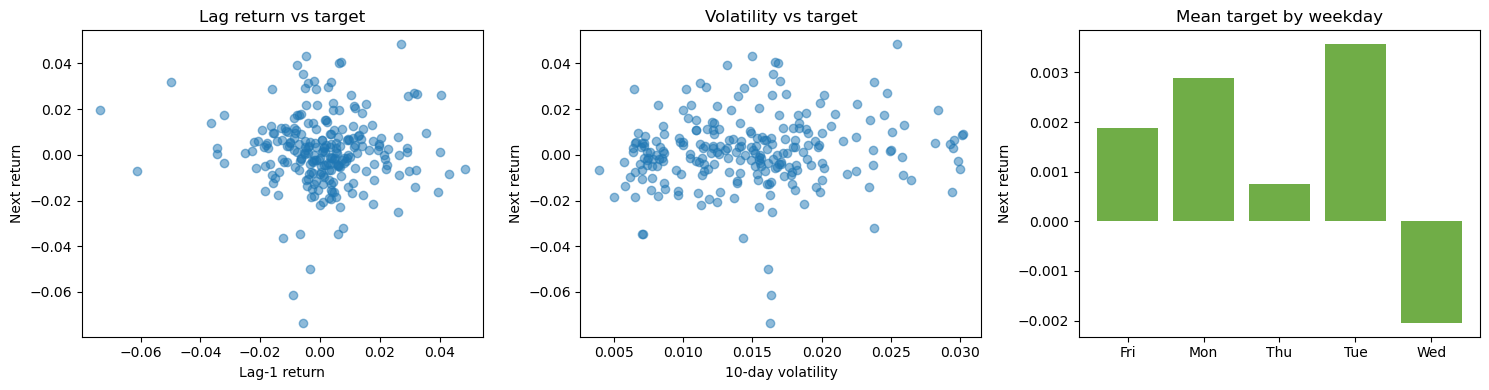

In [4]:
fig,axes=plt.subplots(1,3,figsize=(15,4)); axes[0].scatter(model_df['return_lag1'],model_df['target_next_return'],alpha=.5); axes[0].set(title='Lag return vs target',xlabel='Lag-1 return',ylabel='Next return'); axes[1].scatter(model_df['rolling_std_10'],model_df['target_next_return'],alpha=.5); axes[1].set(title='Volatility vs target',xlabel='10-day volatility',ylabel='Next return'); weekday=[c for c in feature_cols if c.startswith('dow_')]; means=[model_df.loc[model_df[c].eq(1),'target_next_return'].mean() for c in weekday]; axes[2].bar([c[4:7] for c in weekday],means,color='#70AD47'); axes[2].set(title='Mean target by weekday',ylabel='Next return'); plt.tight_layout(); plt.show()

Correlations are small, consistent with Stage 08’s weak predictable structure. That is an important result rather than a reason to discard features: Stage 10 should establish an honest baseline, use regularized/scaled pipelines, and judge usefulness out of sample. Weekday differences may be sampling noise because only one year is represented.